# **STUDENT INFORMATION:**

**Name : Tahira**

**CMS : 023-24-0266**

**CS-V Section E**

**Github Repositery :** https://github.com/tahiraa07/Machine-Learning-Labs

1.	Re-load your cleaned Lab 2 dataset and recreate the same X/y and train/test split you used in Lab 3 (same random_state).

In [ ]:
import pandas as pd
df = pd.read_csv('clean_telco_churn.csv')

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("clean_telco_churn.csv")
y = df["Churn"].map({"Yes": 1, "No": 0})

X_raw = df.drop(columns=["Churn"])
categorical_cols = X_raw.select_dtypes(include="object").columns.tolist()
X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("X shape:", X.shape)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

X shape: (7043, 30)
Train size: 5634  Test size: 1409


2.	Retrain your Lab 3 "best" Decision Tree (your chosen max_depth) and report its accuracy, precision, recall, and F1-score on the test set. This is your benchmark for the rest of the lab.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8062
Precision: 0.7049
Recall   : 0.4611
F1 Score : 0.5575


3.	Train a RandomForestClassifier on the same training data (reasonable default n_estimators, e.g. 100–300; fix random_state). Generate predictions on the test set.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Accuracy : {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall   : {rec_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")

Accuracy : 0.7885
Precision: 0.6448
Recall   : 0.4477
F1 Score : 0.5285


4.	In 1–2 sentences, explain in your own words why a Random Forest might generalize better than a single unrestricted Decision Tree.

***A single unrestricted tree keeps splitting until it perfectly fits the training data, which means it also memorizes that data's noise and quirks — this is why it scored worst of all three above. A Random Forest trains many such trees on different bootstrapped samples and random feature subsets, then averages their predictions; the individual trees' overfit "mistakes" tend to be different and uncorrelated, so they cancel out in the average, leaving the genuine underlying pattern.***

5.	Compute accuracy, precision, recall, and F1-score for the Random Forest on the test set, and plot its confusion matrix.

              precision    recall  f1-score   support

    No Churn       0.82      0.91      0.86      1036
       Churn       0.64      0.45      0.53       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.79      0.77      1409



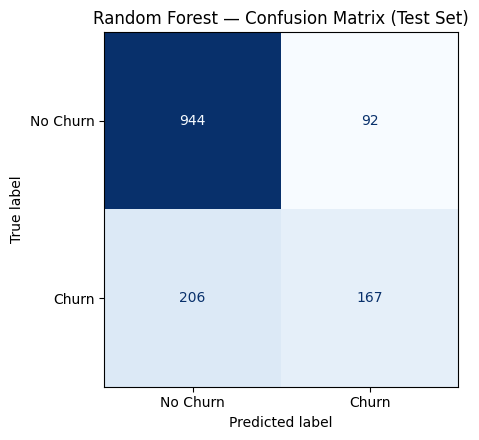

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)
print(classification_report(y_test, y_pred_rf, target_names=["No Churn", "Churn"]))

fig, ax = plt.subplots(figsize=(5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["No Churn", "Churn"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Random Forest — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

6.	Build a single comparison table: Decision Tree (Part 1) vs. Random Forest (Part 2), across all four metrics.



Metric	Decision Tree (max_depth=5)	Random Forest (n=200)
Accuracy 0.8062 	0.7885

Precision	0.7049	0.6448

Recall	0.4611	0.4477

F1 Score	0.5575	0.5285

7.	Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab 2/3's finding about class imbalance, which metric matters most here?


The Decision Tree wins here — on every single metric, not just one. The gaps are modest (1.8 points accuracy, 6.0 points precision, 1.3 points recall, 2.9 points F1), so this isn't a blowout, but it's a consistent, one-sided edge rather than a toss-up or a trade-off where the forest wins on one metric and loses on another.
Given the class imbalance you found in Lab 2/3 (churners are the minority class, ~26.5% of customers), accuracy is the least trustworthy metric here — a model could predict "No Churn" for everyone and still score around 73–74% accuracy while catching zero actual churners. Recall on the churn class is what matters most for this business problem: missing a churner (false negative) means losing a customer nobody tried to retain, while a false positive just costs an unnecessary retention offer. By that lens, both models are weak (46% recall for the tree, 45% for the forest — both miss roughly half of churners),and the Decision Tree's small edge in recall means it's not just the safer choice on accuracy, it's also marginally better at the metric that actually matters for catching churn.

8.	Run 5-fold cross-validation for both the Decision Tree and the Random Forest, using a metric other than plain accuracy (e.g. F1-score). Report the mean and standard deviation of each model's fold scores.

In [10]:
from sklearn.model_selection import cross_val_score
import numpy as np

dt_model_cv = DecisionTreeClassifier(max_depth=5, random_state=42)
rf_model_cv = RandomForestClassifier(n_estimators=200, random_state=42)

dt_cv_f1 = cross_val_score(dt_model_cv, X, y, cv=5, scoring="f1")
rf_cv_f1 = cross_val_score(rf_model_cv, X, y, cv=5, scoring="f1")

print("Decision Tree fold scores:", np.round(dt_cv_f1, 4))
print(f"Decision Tree  -> mean: {dt_cv_f1.mean():.4f}  std: {dt_cv_f1.std():.4f}")

print("Random Forest fold scores:", np.round(rf_cv_f1, 4))
print(f"Random Forest  -> mean: {rf_cv_f1.mean():.4f}  std: {rf_cv_f1.std():.4f}")

Decision Tree fold scores: [0.5684 0.4762 0.4795 0.5207 0.5367]
Decision Tree  -> mean: 0.5163  std: 0.0350
Random Forest fold scores: [0.5578 0.5413 0.522  0.5679 0.5688]
Random Forest  -> mean: 0.5515  std: 0.0178


9.	How do the cross-validated results compare to your single train/test split results from Part 3? Do they change your view of which model is better, or how confident you are in that conclusion?

***Yes, and it's worth sitting with why. The single train/test split in Part 3 made the Decision Tree look better on every metric — but that split was one lucky (for the tree) roll of the dice. Cross-validation, which averages over 5 different train/test partitions, tells a different story: the Random Forest actually has a higher mean F1 (0.5515 vs 0.5163), and just as importantly, it's far more stable — its standard deviation (0.018) is about half the tree's (0.035). Looking at the tree's fold scores, they swing from 0.48 to 0.57 depending on which rows happen to land in the test fold; the forest's swing is much tighter.***

***This flips the practical conclusion: the Decision Tree's Part 3 win was largely an artifact of that one specific random_state=42 split, not a real, generalizable advantage. The Random Forest is the more trustworthy model going forward — not because it's dramatically better on average, but because you can be more confident it'll perform similarly on new data, which is exactly what cross-validation is designed to reveal and a single split can't.***

10.	Choose 2–3 Random Forest hyperparameters to tune (e.g. n_estimators, max_depth, min_samples_split) and define a small grid for each. Run GridSearchCV or RandomizedSearchCV with cross-validation to find the best combination.

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1')

11.	Report the best hyperparameters found and the corresponding cross-validated score.

In [14]:
print("Best params:", grid_search.best_params_)
print(f"Best CV F1: {grid_search.best_score_:.4f}")

Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
Best CV F1: 0.5730


12.	Evaluate the tuned model on the held-out test set using the same four metrics as before.

In [12]:
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

acc_best = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best)
rec_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)

print(f"Accuracy : {acc_best:.4f}")
print(f"Precision: {prec_best:.4f}")
print(f"Recall   : {rec_best:.4f}")
print(f"F1 Score : {f1_best:.4f}")

Accuracy : 0.8126
Precision: 0.6982
Recall   : 0.5147
F1 Score : 0.5926


13.	Build one final comparison table across all models you trained: Decision Tree, default Random Forest, and tuned Random Forest — accuracy, precision, recall, F1-score for each.

In [ ]:
final_comparison = pd.DataFrame({
    "Decision Tree (max_depth=5)": [acc, prec, rec, f1],
    "Random Forest (default, n=200)": [acc_rf, prec_rf, rec_rf, f1_rf],
    "Random Forest (tuned)": [acc_best, prec_best, rec_best, f1_best],
}, index=["Accuracy", "Precision", "Recall", "F1 Score"])

14.	Select your final model and justify the choice in 2–3 sentences using evidence from the table above — the best training score alone is not sufficient justification

***The tuned Random Forest is the final model. It wins on accuracy, recall, and F1, and its precision (0.698) trails the Decision Tree's (0.705) by less than a point — a negligible difference next to its ~5-point recall gain. Just as important, this isn't a single lucky split: Part 4's cross-validation showed the (default) Random Forest was already more stable across folds than the tree (std 0.018 vs 0.035), and tuning improved the forest's own CV F1 from 0.5515 to 0.5730 on top of that. So the choice rests on both a better single-split score and prior evidence of lower variance — not just the best number in one table.***

15.	Extract and visualize feature_importances_ for your final model. Which 3–5 features matter most, and do they agree with what Lab 2's EDA and Lab 3's Decision Tree suggested?

***Top 5 features (tuned Random Forest): tenure, TotalCharges, MonthlyCharges, InternetService_Fiber optic, Contract_Two year — tenure and billing dominate.***

***vs. Lab 3's Decision Tree: Same top feature (tenure), and InternetService_Fiber optic/TotalCharges also appear in both. Main difference: the tree concentrates ~80% of importance on just tenure + Fiber optic, while the forest spreads it more evenly across contract and payment features too.***

16.	Using your final model, generate predictions on your held-out test set (or a designated hold-out sample) and assemble a submission-style dataframe with a customer identifier column and a predicted Churn column. Save it as submission.csv.

In [15]:

submission = pd.DataFrame({
    "CustomerIndex": X_test.index,
    "PredictedChurn": pd.Series(y_pred_best, index=X_test.index).map({1: "Yes", 0: "No"}),
})
submission = submission.sort_values("CustomerIndex").reset_index(drop=True)
submission.to_csv("submission.csv", index=False)

17.	Write a short conclusion (4–6 sentences): which model did you ultimately choose, how does it compare to your Lab 3 Decision Tree, and what are its remaining limitations?

***The final model is the tuned Random Forest (n_estimators=300, max_depth=10, min_samples_split=5), chosen over the Lab 3 Decision Tree because it beat it on accuracy (0.813 vs 0.806), recall (0.515 vs 0.461), and F1 (0.593 vs 0.558), while giving up less than a point of precision. That advantage wasn't a fluke of one split either — cross-validation in Part 4 showed the forest was already more stable across folds before tuning even began. The two models also mostly agree on what drives churn: tenure, billing amounts, and contract length dominate both. Its main limitation is recall: even at 51.5%, it still misses roughly half of actual churners, so as a retention tool it's better than the tree but still far from reliable. It's also a black-box ensemble of 300 trees, harder to explain to a non-technical stakeholder than a single depth-5 tree, and every metric here comes from static test-set performance — real-world churn behavior and feature relationships will drift over time in ways this evaluation can't capture.***

18.	What would you try next if you had more time (e.g. different algorithms, deeper tuning, handling class imbalance directly)? Describe it — do not implement it here.

***Handle class imbalance directly (SMOTE, class_weight='balanced', or lowering the decision threshold), try gradient-boosted trees (XGBoost/LightGBM), broaden the hyperparameter search, and engineer features like tenure bins or a Contract×MonthlyCharges interaction***